In `waveguide` we have several helper functions for constructing the domain

In [1]:
from problems.waveguide import Clean
Clean?

Signature:
Clean(
    H: float = 1.0,
    R: float = 5.0,
    lc: float = 0.3,
    verbose: bool = False,
) -> problems.waveguide.base.WaveguideDomain
Docstring:
Creates a domain corresponging to a waveguide without scatterers.
It assumes the default tags for the subregions, i.e.:
- Omega
- Gamma
- Sigma
File:      ~/Documentos/Trefftz/problems/waveguide/base.py
Type:      function

Lets create a clean waveguide and plot it:

In [2]:
H = 1.0 
R = 5.0
lc = 0.3
domain = Clean(H=H, R=R, lc=lc, verbose=True)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000194231s, CPU 0.000152s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00283162s, CPU 0.003828s)
Info    : 181 nodes 364 elements


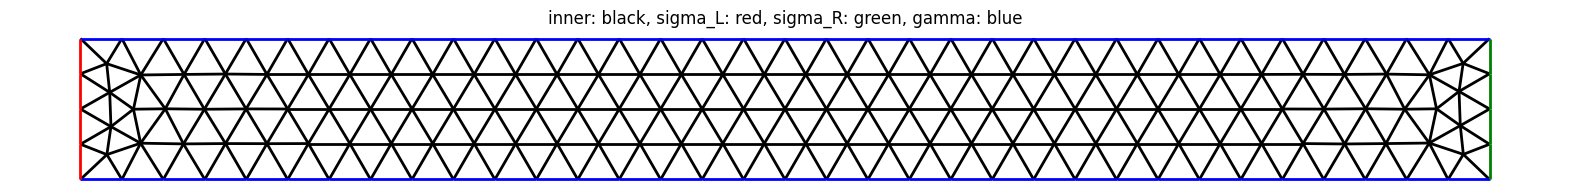

In [3]:
domain.plot(line_width=2)

To define our problem we also need a set of basis functions: linearly spaced plane waves, evanescent waves...

In [4]:
from trefftz.dg.basis import LinearlySpacedBasis

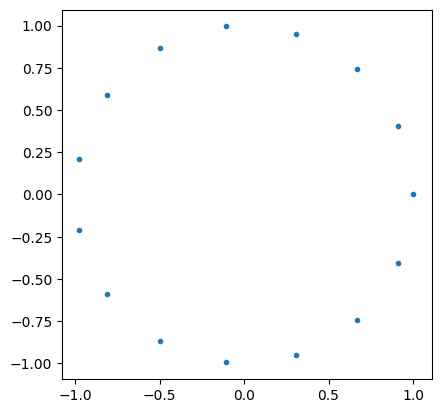

In [5]:
N_theta = 15
kappa = 8.
basis = LinearlySpacedBasis(N_elements=domain.mesh.n_triangles, k=kappa, N_theta=N_theta)
basis.plot_directions()

Now we are prepared to define a problem ( in the future we will need to define the type of assembly we are going to do: serial, block, parallel... right now only the serial one is implemented)

In [6]:
from problems.waveguide import WaveguideProblem
M = 10
problem = WaveguideProblem( domain=domain, basis=basis, k=kappa, NtD_modes=M)

we cannot assemble the problem yet, as no boundary conditions were specified

In [7]:
problem.assembleMatrix()

no boundary conditions specified, use .set_boundary_conditions


In order to set them we need to specify a type of flux at each region:

In [8]:
regions = problem.domain.regions
list(regions)

[<WaveguideRegions.OMEGA: 0>,
 <WaveguideRegions.GAMMA: 1>,
 <WaveguideRegions.SIGMA_L: 3>,
 <WaveguideRegions.SIGMA_R: 4>,
 <WaveguideRegions.SIGMA: 2>,
 <WaveguideRegions.D_OMEGA: 5>]

In [9]:
from trefftz.dg.fluxes import FluxType
list(FluxType)

[<FluxType.TRANSMISSION: 0>,
 <FluxType.SOUNDHARD: 1>,
 <FluxType.SOUNDSOFT: 2>,
 <FluxType.RADIATING: 3>,
 <FluxType.DIRICHLET: 4>,
 <FluxType.NEUMANN: 5>]

In [10]:
problem.set_boundary_conditions({
    regions.GAMMA: FluxType.SOUNDHARD,  # NEUMANN IS NOT THE SAME AS SOUND HARD, SOUNDHARD IS NEUMANN HOMOGENEOUS
    regions.OMEGA: FluxType.TRANSMISSION,
    regions.SIGMA_L: FluxType.RADIATING,
    regions.SIGMA_R: FluxType.RADIATING
})

In [11]:
problem.assembleMatrix()

Now we need to choose among a list of right hand sides (this should be cleaner, probably synchronized with the choice of BND conditions)

In [12]:
from problems.waveguide.RHS_types import RHS_type
list(RHS_type)

[<RHS_type.MODE: 0>]

Let's try the second mode

In [18]:
problem.assembleRHS(RHS_type.MODE,{"t": 1})

Now we can solve the problem

In [19]:
u = problem.solve()

And plot the solution on the domain:

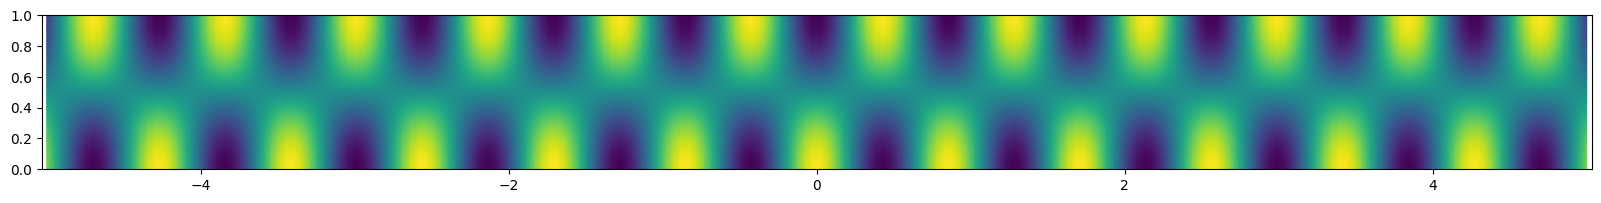

In [20]:
problem.plot_trefftz_function(u)

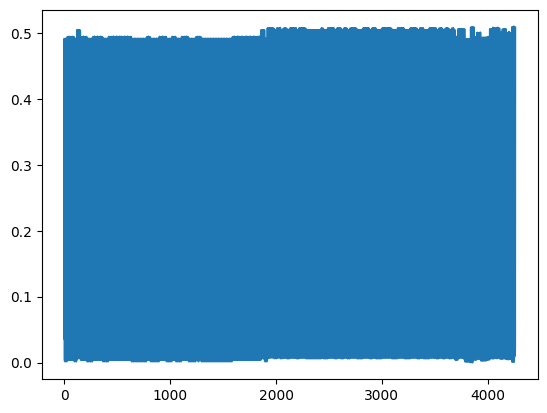

In [21]:
import matplotlib.pyplot as plt 
import numpy as np
plt.plot(np.abs(u.coefficients))